# Cardiovascular Disease Prediction Project

## Project Title

This notebook analyzes the Cardiovascular Study Dataset and builds a logistic regression model to predict the 10-year risk of coronary heart disease (CHD).

## Project Goal
To build a logistic regression model that predicts whether 
a patient will develop coronary heart disease (CHD) within 
the next 10 years based on their demographic, lifestyle 
and clinical characteristics.

## Brief Introduction

Cardiovascular disease remains one of the leading causes of death worldwide. Predictive modeling can support early risk identification and help clinicians focus on patients who may need further evaluation.

## Main Problem Question

Can we build a reliable logistic regression model that predicts whether a patient is likely to develop coronary heart disease within 10 years using available health indicators?

## Data Source and Variable Explanation

The dataset used in this project is the Cardiovascular Study Dataset. Below is a brief glossary of the 17 variables so the viewer can clearly understand what each field represents.

- `id`: A unique identifier for each patient record in the dataset.
- `age`: The age of the patient in years.
- `education_level`: The patient's education level, usually recorded as an ordinal category showing the highest level completed.
- `sex`: The biological sex of the patient, recorded as male or female.
- `smoking_status`: Indicates whether the patient is currently a smoker.
- `cigarettes_per_day`: The average number of cigarettes the patient smokes per day.
- `blood_pressure_medication`: Indicates whether the patient is taking medication for blood pressure.
- `history_of_stroke`: Indicates whether the patient has previously had a stroke.
- `history_of_hypertension`: Indicates whether the patient has a history of hypertension, meaning persistently high blood pressure.
- `diabetes`: Indicates whether the patient has diabetes.
- `total_cholesterol`: The patient's total cholesterol level, which is an important cardiovascular risk indicator.
- `systolic_blood_pressure`: Systolic blood pressure, which measures the pressure in the arteries when the heart beats.
- `diastolic_blood_pressure`: Diastolic blood pressure, which measures the pressure in the arteries when the heart rests between beats.
- `body_mass_index`: Body Mass Index, a measure based on height and weight that is used to assess body fatness.
- `heart_rate`: The patient's heart rate, usually measured in beats per minute.
- `blood_glucose`: The patient's blood glucose level, which helps indicate blood sugar status and possible diabetes risk.
- `ten_year_chd`: The target variable showing whether the patient is predicted to develop coronary heart disease within the next 10 years (`1` = yes, `0` = no).

These variables combine demographic, lifestyle, and clinical information, making them useful for estimating long-term CHD risk.

In [82]:
import pandas as pd


In [83]:
import numpy as np


In [84]:
import matplotlib.pyplot as plt


In [85]:
import seaborn as sns


In [86]:
from pathlib import Path


In [87]:
from IPython.display import display

In [88]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict


In [89]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

## Library Imports

These imports cover the full workflow: file handling, exploration, plotting, preprocessing, feature selection, model tuning, threshold optimisation, and evaluation. `mutual_info_classif` is added so feature selection is driven by measured signal instead of only manual choice.

In [90]:
df = pd.read_csv("train.csv")

rename_map = {
    'is_smoking': 'smoking_status',
    'cigsPerDay': 'cigarettes_per_day',
    'BPMeds': 'blood_pressure_medication',
    'prevalentStroke': 'history_of_stroke',
    'prevalentHyp': 'history_of_hypertension',
    'education': 'education_level',
    'totChol': 'total_cholesterol',
    'sysBP': 'systolic_blood_pressure',
    'diaBP': 'diastolic_blood_pressure',
    'BMI': 'body_mass_index',
    'heartRate': 'heart_rate',
    'glucose': 'blood_glucose',
    'TenYearCHD': 'ten_year_chd'
}

df = df.rename(columns=rename_map)

if 'id' in df.columns:
    df = df.drop(columns='id')

target = 'ten_year_chd'

print('Working shape:', df.shape)
df.head()

Working shape: (3390, 16)


,age,education_level,sex,smoking_status,cigarettes_per_day,blood_pressure_medication,history_of_stroke,history_of_hypertension,diabetes,total_cholesterol,systolic_blood_pressure,diastolic_blood_pressure,body_mass_index,heart_rate,blood_glucose,ten_year_chd
0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


## Data Loading

The dataset is loaded from the first available path and the `id` column is removed immediately because it is only a record identifier. That keeps every later step focused on predictive variables and avoids carrying a non-informative feature through EDA, preprocessing, and modelling.

## Basic EDA

We begin by inspecting the shape, variable types, missing values, and target distribution. This gives us a first understanding of the dataset before any modeling steps.

In [91]:
print('Shape:', df.shape)
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Shape: (3390, 16)

Data types:


,dtype
age,int64
education_level,float64
sex,str
smoking_status,str
cigarettes_per_day,float64
blood_pressure_medication,float64
history_of_stroke,int64
history_of_hypertension,int64
diabetes,int64
total_cholesterol,float64


In [92]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
print('\nMissing values by column:')
display(missing_summary.to_frame('missing_count'))


Missing values by column:


,missing_count
blood_glucose,304
education_level,87
blood_pressure_medication,44
total_cholesterol,38
cigarettes_per_day,22
body_mass_index,14
heart_rate,1
age,0
history_of_hypertension,0
history_of_stroke,0


In [93]:
print('\nTarget distribution (proportion):')
display(df[target].value_counts(normalize=True).rename('proportion').to_frame())


Target distribution (proportion):


,proportion
ten_year_chd,
0,0.849263
1,0.150737


In [94]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,3390.0,NaN,NaN,NaN,49.542183,8.592878,32.0,42.0,49.0,56.0,70.0
education_level,3303.0,NaN,NaN,NaN,1.970936,1.019081,1.0,1.0,2.0,3.0,4.0
sex,3390,2,F,1923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,3390,2,NO,1703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cigarettes_per_day,3368.0,NaN,NaN,NaN,9.069477,11.879078,0.0,0.0,0.0,20.0,70.0
blood_pressure_medication,3346.0,NaN,NaN,NaN,0.029886,0.170299,0.0,0.0,0.0,0.0,1.0
history_of_stroke,3390.0,NaN,NaN,NaN,0.00649,0.080309,0.0,0.0,0.0,0.0,1.0
history_of_hypertension,3390.0,NaN,NaN,NaN,0.315339,0.464719,0.0,0.0,0.0,1.0,1.0
diabetes,3390.0,NaN,NaN,NaN,0.025664,0.158153,0.0,0.0,0.0,0.0,1.0
total_cholesterol,3352.0,NaN,NaN,NaN,237.074284,45.24743,107.0,206.0,234.0,264.0,696.0


## Basic Inspection Summary

This inspection confirms the dataset size, the mixture of numeric and text-based categorical fields, and where missing values are concentrated. The target distribution also shows a clear class imbalance, which is important for later model design because standard accuracy alone would be misleading in an imbalanced medical screening problem.

## Data Cleaning (Pre-EDA)
Before any modeling transformations, we first profile and clean the full dataset for obvious data-quality issues (text inconsistencies, duplicates, and smoking-status contradictions). This keeps issue detection explicit and separate from train-only preprocessing that comes later.

In [104]:
audit_df = df.copy()

for col in ['sex', 'smoking_status']:
    audit_df[col] = audit_df[col].apply(lambda value: value.strip().upper() if isinstance(value, str) else value)

duplicate_count = audit_df.duplicated().sum()
smoking_contradictions = audit_df[
    ((audit_df['smoking_status'] == 'NO') & (audit_df['cigarettes_per_day'].fillna(0) > 0))
    | ((audit_df['smoking_status'] == 'YES') & (audit_df['cigarettes_per_day'].fillna(0) == 0))
].copy()

education_summary = audit_df['education_level'].value_counts(dropna=False).sort_index().rename('count')
missing_summary = audit_df.isnull().sum().sort_values(ascending=False).rename('missing_count')

print('Duplicate rows identified:', duplicate_count)
print('Smoking contradictions identified:', len(smoking_contradictions))
if not smoking_contradictions.empty:
    display(smoking_contradictions.head())


Duplicate rows identified: 0
Smoking contradictions identified: 22


,age,education_level,sex,smoking_status,cigarettes_per_day,blood_pressure_medication,history_of_stroke,history_of_hypertension,diabetes,total_cholesterol,systolic_blood_pressure,diastolic_blood_pressure,body_mass_index,heart_rate,blood_glucose,ten_year_chd
422,55,1.0,F,YES,NaN,0.0,0,1,0,213.0,163.0,91.0,28.66,69.0,66.0,0
466,45,3.0,M,YES,NaN,0.0,0,1,0,170.0,145.5,99.0,26.74,83.0,85.0,0
469,42,1.0,M,YES,NaN,0.0,0,0,0,196.0,123.0,73.0,22.06,66.0,NaN,0
491,61,1.0,F,YES,NaN,0.0,0,1,0,356.0,168.0,98.0,27.30,103.0,106.0,0
538,41,1.0,F,YES,NaN,0.0,0,0,0,171.0,135.0,82.5,24.35,79.0,82.0,0


In [105]:
print('\nMissing values by column:')
display(missing_summary[missing_summary > 0].to_frame())



Missing values by column:


,missing_count
blood_glucose,304
education_level,87
blood_pressure_medication,44
total_cholesterol,38
cigarettes_per_day,22
body_mass_index,14
heart_rate,1


In [106]:
audit_numeric_features = [
    'age',
    'cigarettes_per_day',
    'total_cholesterol',
    'systolic_blood_pressure',
    'diastolic_blood_pressure',
    'body_mass_index',
    'heart_rate',
    'blood_glucose'
 ]

outlier_rows = []
for col in audit_numeric_features:
    series = audit_df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((audit_df[col] < lower) | (audit_df[col] > upper)).sum()
    outlier_rows.append({
        'feature': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(outlier_count),
        'outlier_pct': round(100 * outlier_count / len(audit_df), 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_count', ascending=False).reset_index(drop=True)

print('\nIQR-based outlier counts on the full dataset:')
display(outlier_summary)




IQR-based outlier counts on the full dataset:


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,blood_glucose,47.00,111.00,158,4.66
1,systolic_blood_pressure,76.50,184.50,105,3.10
2,body_mass_index,15.49,35.57,77,2.27
3,heart_rate,45.50,105.50,64,1.89
4,diastolic_blood_pressure,51.25,113.25,58,1.71
5,total_cholesterol,119.00,351.00,43,1.27
6,cigarettes_per_day,-30.00,50.00,9,0.27
7,age,21.00,77.00,0,0.00


In [108]:
audit_encoded = audit_df.copy()
audit_encoded['sex'] = audit_encoded['sex'].map({'F': 0, 'M': 1})
audit_encoded['smoking_status'] = audit_encoded['smoking_status'].map({'NO': 0, 'YES': 1})

corr_abs = audit_encoded.corr(numeric_only=True).abs()
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_correlation'})
    .query('abs_correlation > 0.75')
    .sort_values('abs_correlation', ascending=False)
    .reset_index(drop=True)
)

print('\nHighly correlated feature pairs (absolute correlation > 0.75):')
if high_corr_pairs.empty:
    print('No high-correlation pairs above the threshold.')
else:
    display(high_corr_pairs)


Highly correlated feature pairs (absolute correlation > 0.75):


,feature_1,feature_2,abs_correlation
0,systolic_blood_pressure,diastolic_blood_pressure,0.781908
1,smoking_status,cigarettes_per_day,0.772261


This checking stage reports data quality issues on the full dataset without changing the modeling dataset. After the issues are identified and reviewed, cleaning is applied in the next step: text standardization, duplicate removal, and smoking-status contradiction correction.

In [109]:
df_clean = df.copy()

for col in ['sex', 'smoking_status']:
    df_clean[col] = df_clean[col].apply(lambda value: value.strip().upper() if isinstance(value, str) else value)

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
rows_after = len(df_clean)

df_clean.loc[
    (df_clean['smoking_status'] == 'NO') & (df_clean['cigarettes_per_day'].fillna(0) > 0),
    'smoking_status'
] = 'YES'

remaining_contradictions = df_clean[
    ((df_clean['smoking_status'] == 'NO') & (df_clean['cigarettes_per_day'].fillna(0) > 0))
    | ((df_clean['smoking_status'] == 'YES') & (df_clean['cigarettes_per_day'].fillna(0) == 0))
]

print('Rows before cleaning:', rows_before)
print('Rows after duplicate removal:', rows_after)
print('Rows removed as duplicates:', rows_before - rows_after)
print('Remaining smoking contradictions after correction:', len(remaining_contradictions))
print('\nShape after cleaning:', df_clean.shape)
df_clean.head()

Rows before cleaning: 3390
Rows after duplicate removal: 3390
Rows removed as duplicates: 0
Remaining smoking contradictions after correction: 22

Shape after cleaning: (3390, 16)


,age,education_level,sex,smoking_status,cigarettes_per_day,blood_pressure_medication,history_of_stroke,history_of_hypertension,diabetes,total_cholesterol,systolic_blood_pressure,diastolic_blood_pressure,body_mass_index,heart_rate,blood_glucose,ten_year_chd
0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


## EDA on the Full Dataset

This exploratory analysis is performed on the full cleaned dataset before any train-test split or class balancing. 

In [100]:
eda_df = df_clean.copy()

print('EDA dataset shape:', eda_df.shape)
print('\nTarget counts on the full cleaned dataset:')
display(eda_df[target].value_counts().rename('count').to_frame())
print('\nTarget proportions on the full cleaned dataset:')
display(eda_df[target].value_counts(normalize=True).rename('proportion').to_frame())

EDA dataset shape: (3390, 16)

Target counts on the full cleaned dataset:


,count
ten_year_chd,
0,2879
1,511



Target proportions on the full cleaned dataset:


,proportion
ten_year_chd,
0,0.849263
1,0.150737


This cell confirms that every EDA chart below uses the full cleaned dataset. The class distribution remains imbalanced, but the key point is that the descriptive analysis still reflects the entire observed population.

## Numeric Feature Distributions

These charts compare the distributions of the main numeric variables across CHD outcomes on the full dataset. Looking at the full sample here makes the shifts in age, blood pressure, cholesterol, glucose, and smoking intensity easier to judge visually.

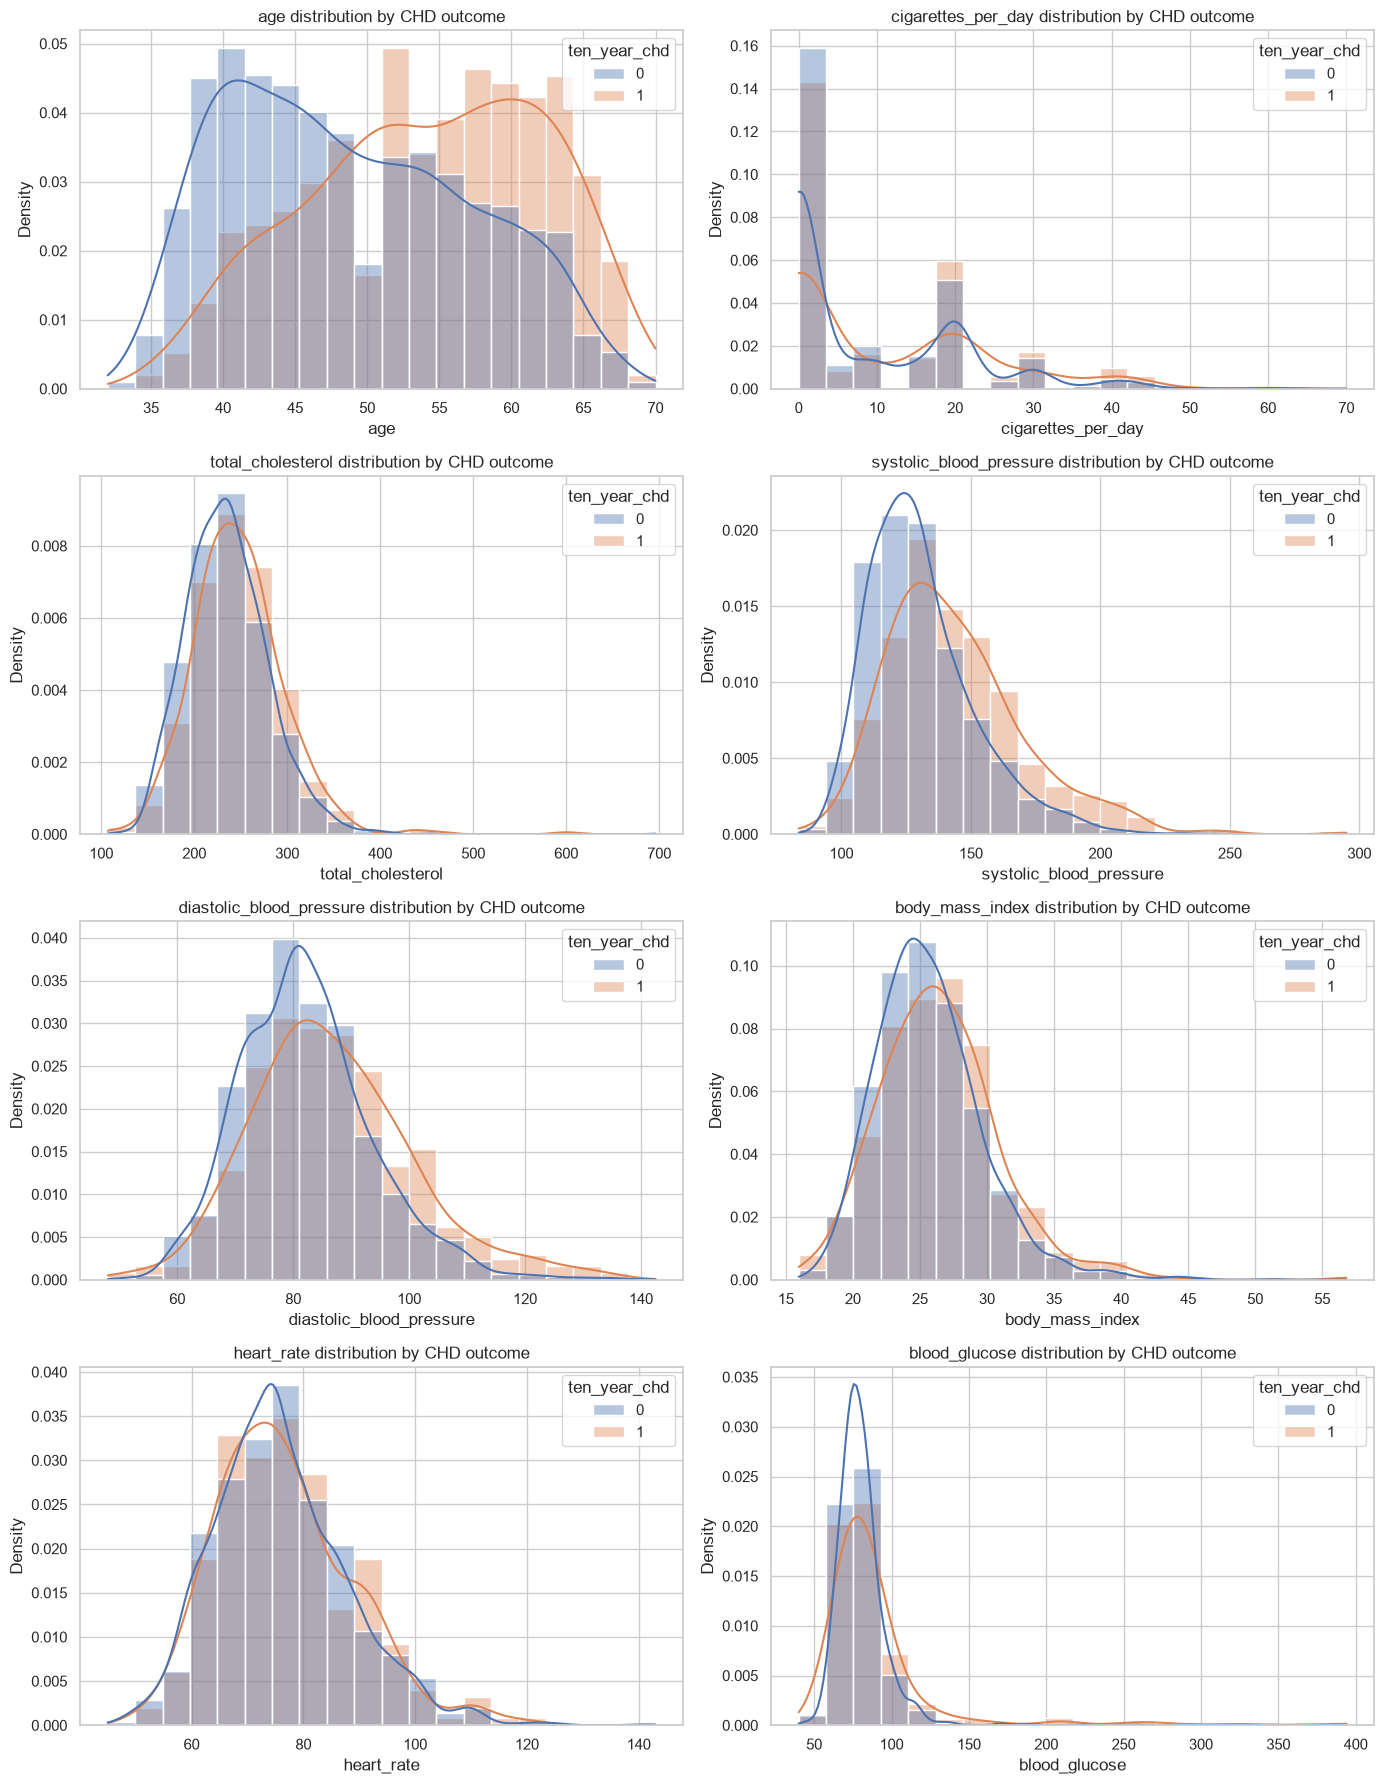

In [101]:
numeric_features = ['age', 'cigarettes_per_day', 'total_cholesterol', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'body_mass_index', 'heart_rate', 'blood_glucose']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    temp = eda_df[[col, target]].dropna()
    sns.histplot(
        data=temp,
        x=col,
        hue=target,
        bins=20,
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.4,
        ax=ax
    )
    ax.set_title(f'{col} distribution by CHD outcome')

for ax in axes[len(numeric_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

The numeric distributions show which variables shift most clearly between the two outcome groups. In this dataset, older age and higher blood-pressure-related measurements tend to lean more strongly toward CHD cases, while several other variables still overlap substantially and therefore contribute weaker standalone separation.

## Categorical Feature Distributions

These plots show how the main categorical and binary predictors are distributed across the target classes on the full dataset. They help identify whether CHD cases are concentrated within particular smoking, medication, hypertension, diabetes, or education groups.

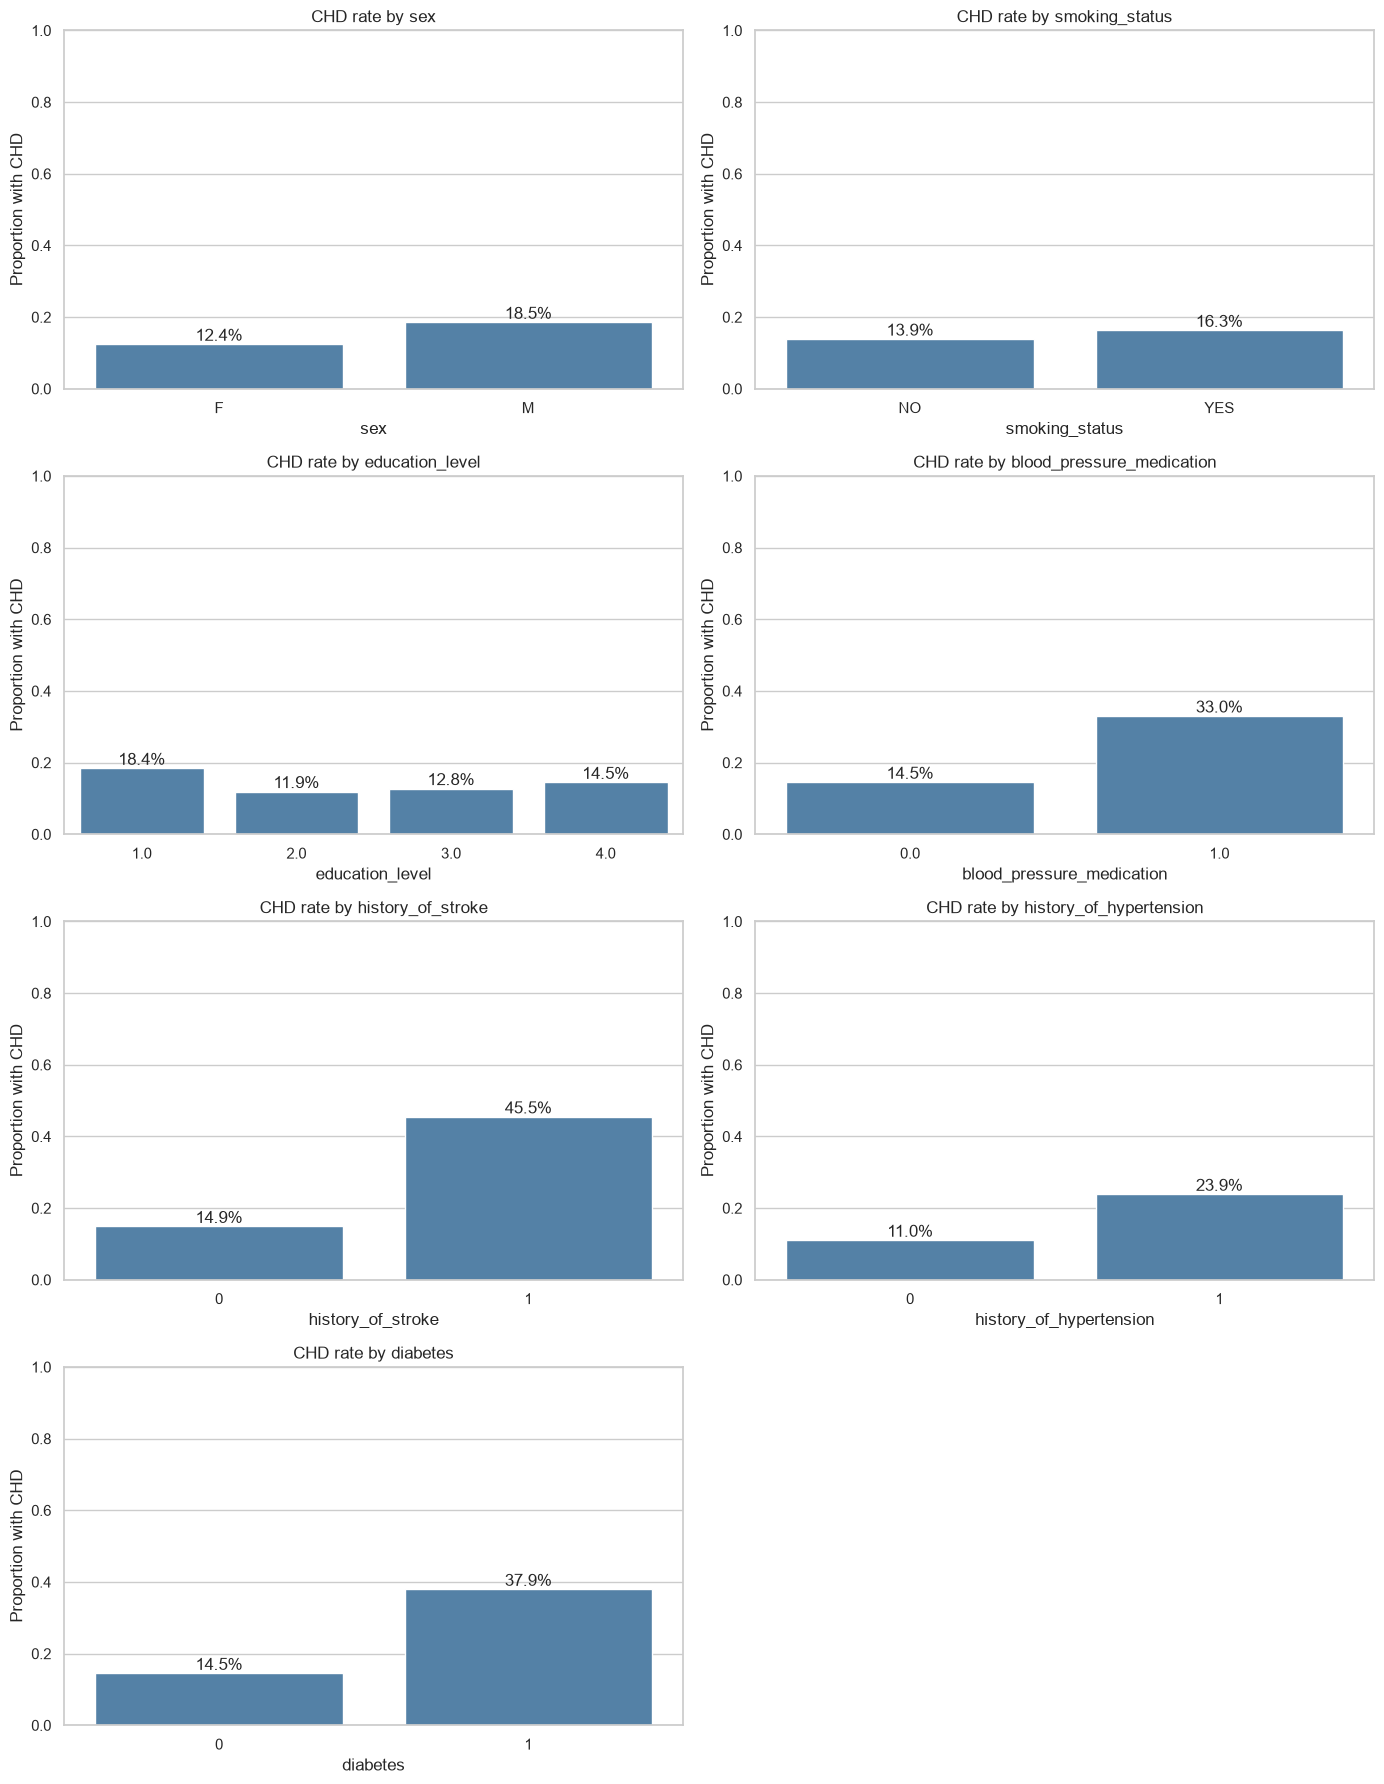

In [111]:
categorical_features = ['sex', 'smoking_status', 'education_level', 'blood_pressure_medication', 'history_of_stroke', 'history_of_hypertension', 'diabetes']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):

    prop_df = (eda_df.groupby(col)[target]
               .mean()
               .reset_index()
                .rename(columns={target: 'CHD_rate'}))

    sns.barplot(
        data=prop_df,
        x=col,
        y='CHD_rate',
        ax=ax,
        color='steelblue'
    )
    ax.set_title(f'CHD rate by {col}')
    ax.set_ylabel('Proportion with CHD')
    ax.set_ylim(0, 1)

    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.1%}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom'
            )

for ax in axes[len(categorical_features):]:
    ax.axis('off') 

plt.tight_layout()
plt.show()

These categorical plots provide a direct view of how often CHD occurs within major clinical and lifestyle groups. Features such as hypertension, diabetes, blood-pressure medication status, and smoking are especially useful here because they show whether the positive class becomes more common in clinically higher-risk categories.

## Box Plots for Outlier Review

We prepared box plots for three evidence-based reasons:

1. They show **median, IQR, and extreme tails** in one view, so we can detect skew and outliers that a mean table hides.
2. They let us compare CHD vs non-CHD spreads per feature and check whether one class has systematically heavier tails.
3. They directly support the next preprocessing step: **IQR-based capping**. The same IQR concept used visually here is later used numerically on training data to define lower and upper caps.

So the box plots are not decorative; they are the diagnostic link between raw-distribution behavior and our outlier-handling rule.

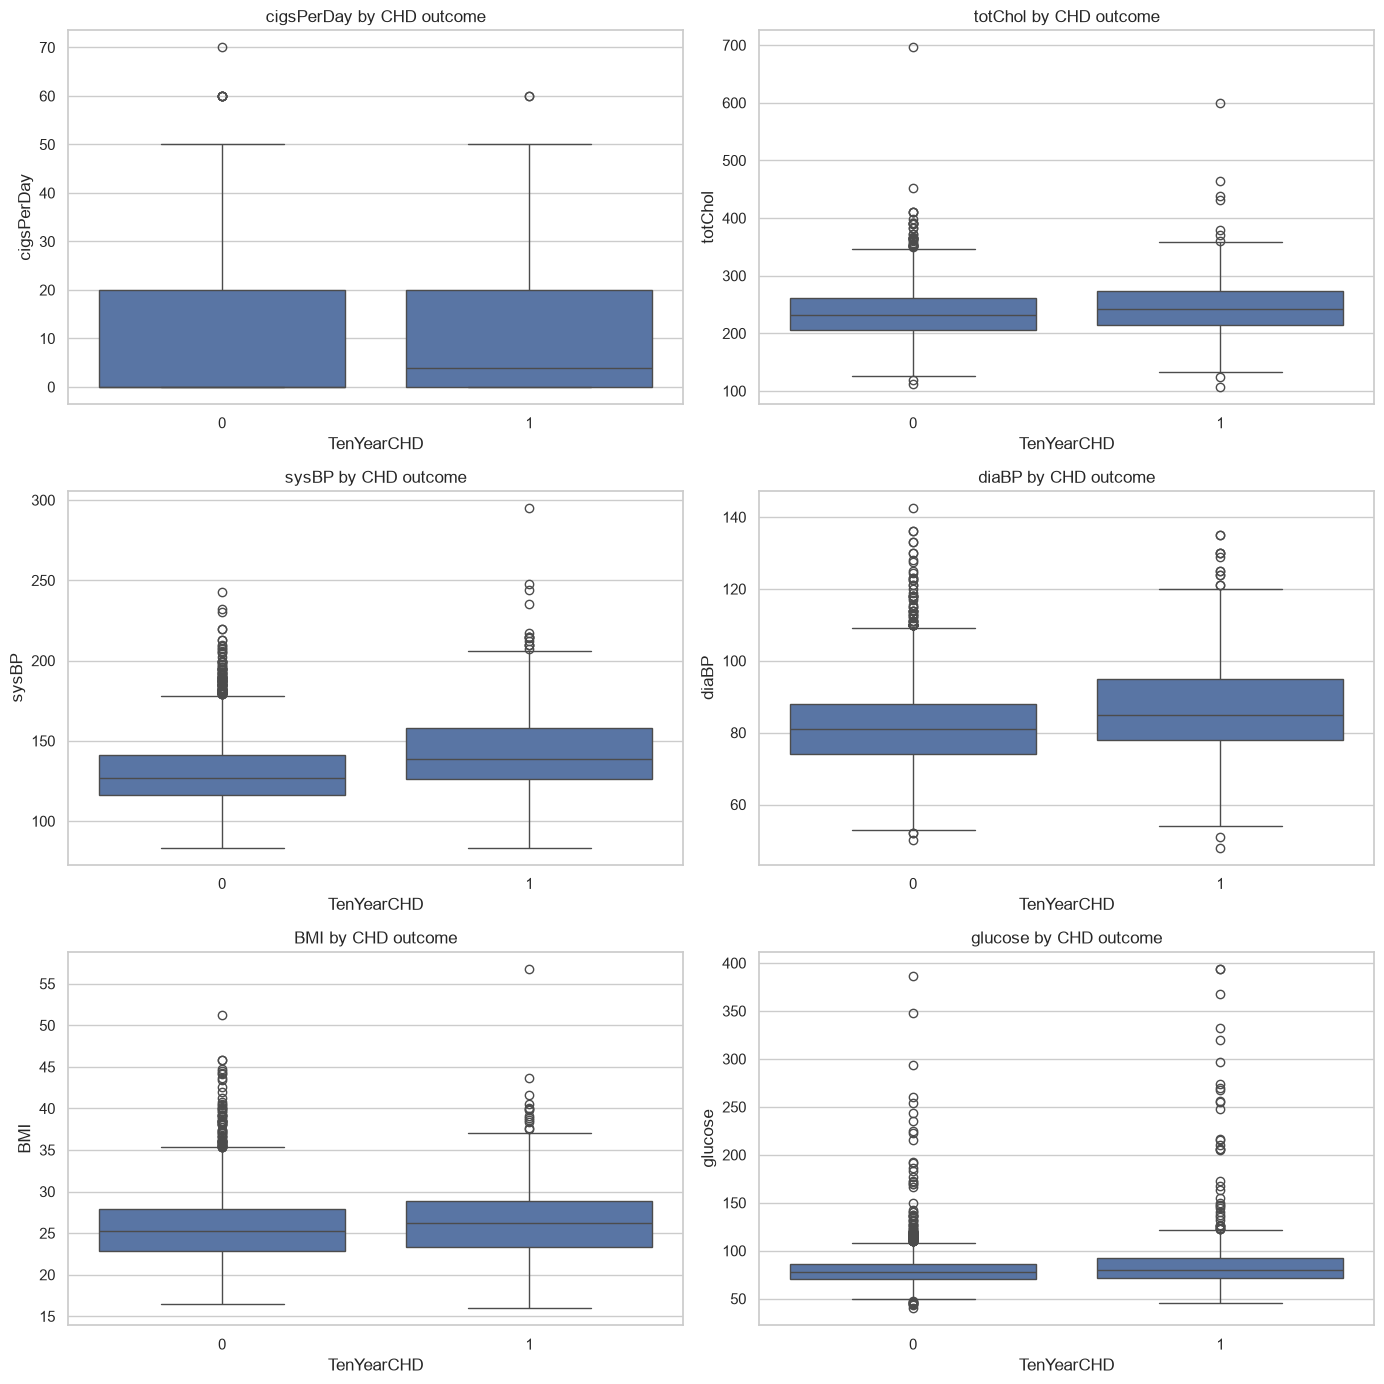

In [23]:
boxplot_features = ['cigarettes_per_day', 'total_cholesterol', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'body_mass_index', 'blood_glucose']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, col in zip(axes, boxplot_features):
    temp = eda_df[[col, target]].dropna()
    sns.boxplot(data=temp, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by CHD outcome')

for ax in axes[len(boxplot_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

The box plots show that several continuous predictors have long right tails and many points beyond the whiskers, especially `blood_glucose`, `systolic_blood_pressure`, and `total_cholesterol`. This is exactly why we cap outliers later: to reduce extreme-value leverage in logistic regression while keeping all records. The key guardrail remains unchanged: cap thresholds are learned on training data only, then applied to test data to avoid leakage.

## Correlation Analysis

The correlation heatmap below is built from an encoded version of the full cleaned dataset and includes the numeric correlation values directly on the chart. This makes both target associations and multicollinearity patterns easier to read.

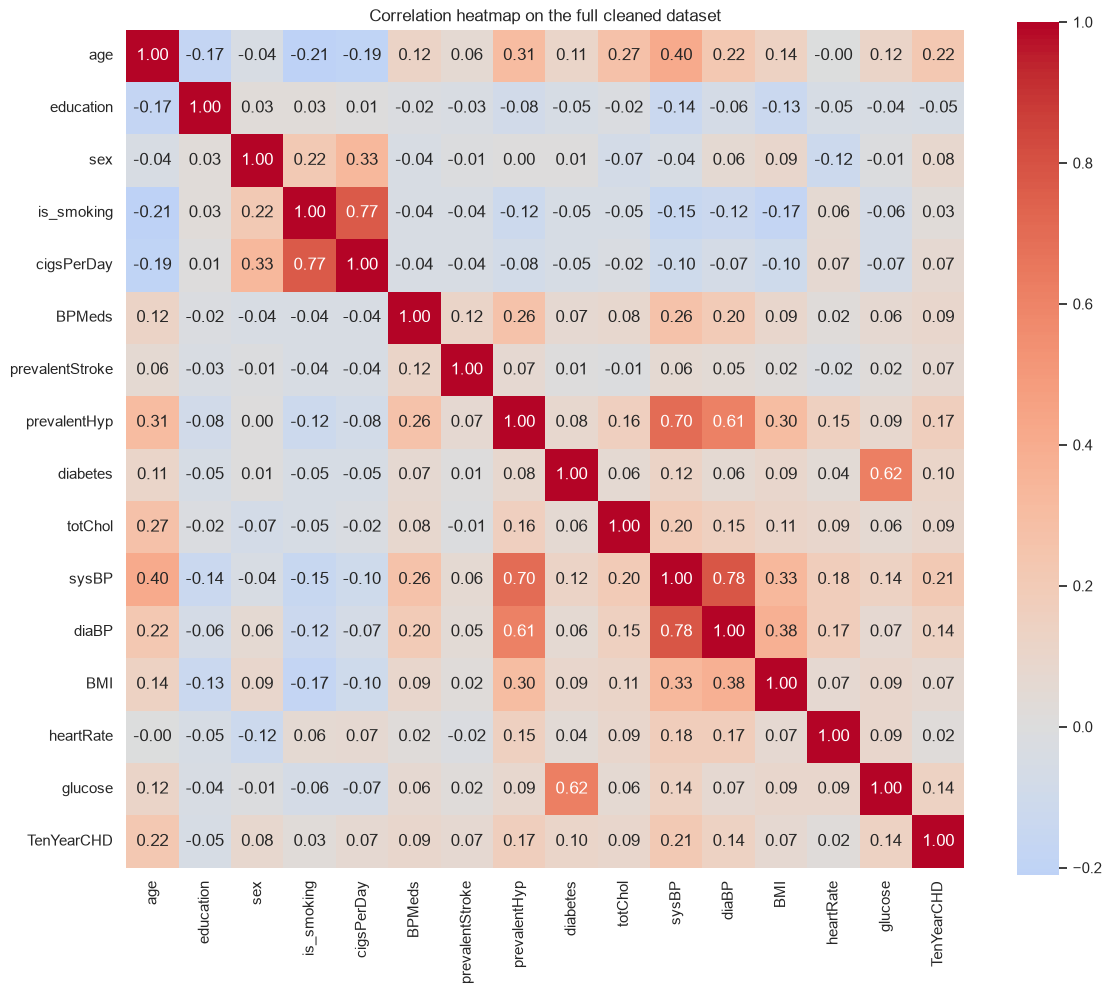

Correlation with the target variable:


,correlation_with_TenYearCHD
age,0.224927
sysBP,0.212703
prevalentHyp,0.166544
glucose,0.138200
diaBP,0.135979
diabetes,0.103681
totChol,0.094306
BPMeds,0.088020
sex,0.084647
prevalentStroke,0.068627


In [24]:
eda_encoded = eda_df.copy()
eda_encoded['sex'] = eda_encoded['sex'].map({'F': 0, 'M': 1})
eda_encoded['smoking_status'] = eda_encoded['smoking_status'].map({'NO': 0, 'YES': 1})

corr_matrix = eda_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title(f'Correlation heatmap on the full cleaned dataset')
plt.tight_layout()
plt.show()

target_correlations = corr_matrix[target].drop(target).sort_values(key=np.abs, ascending=False)
print('Correlation with the target variable:')
display(target_correlations.to_frame('correlation_with_ten_year_chd'))

The annotated heatmap lets you read the size and direction of each correlation directly instead of estimating it from color alone. It is particularly helpful for spotting pairs such as systolic versus diastolic blood pressure or smoking status versus cigarettes per day, where strong feature overlap can affect coefficient stability later.

## Feature Relationships With the Target

Beyond the global correlation matrix, the next cell summarises how each feature changes across the CHD classes. This gives a more direct feature-to-target view that supports later feature selection with measurable evidence.

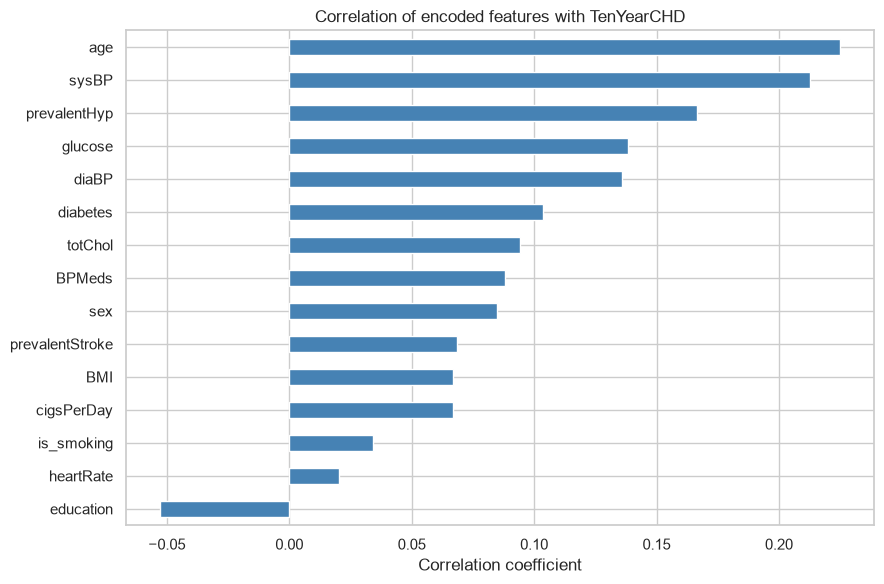

Numeric feature means by target class:


TenYearCHD,CHD_0_mean,CHD_1_mean,mean_difference
sysBP,130.603856,143.854207,13.250352
totChol,235.279494,247.216270,11.936775
glucose,80.662969,89.970339,9.307370
age,48.728031,54.129159,5.401128
diaBP,82.194338,86.763209,4.568871
cigsPerDay,8.734430,10.947059,2.212629
BMI,25.679565,26.452560,0.772995
heartRate,75.875304,76.552941,0.677637



CHD rate by sex:


,CHD_rate
sex,
M,0.185412
F,0.124285



CHD rate by is_smoking:


...

,CHD_rate
prevalentStroke,
1,0.454545
0,0.148753



CHD rate by prevalentHyp:


,CHD_rate
prevalentHyp,
1,0.238541
0,0.110297



CHD rate by diabetes:


,CHD_rate
diabetes,
1,0.379310
0,0.144717


In [25]:
plt.figure(figsize=(9, 6))
target_correlations.sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Correlation of encoded features with {target}')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

numeric_relationships = (
    eda_df.groupby(target)[numeric_features]
    .mean()
    .T
    .rename(columns={0: 'CHD_0_mean', 1: 'CHD_1_mean'})
)
numeric_relationships['mean_difference'] = numeric_relationships['CHD_1_mean'] - numeric_relationships['CHD_0_mean']
print('Numeric feature means by target class:')
display(numeric_relationships.sort_values('mean_difference', key=np.abs, ascending=False))

for col in categorical_features:
    temp = eda_df[[col, target]].dropna()
    category_rates = temp.groupby(col)[target].mean().sort_values(ascending=False)
    print(f'\nCHD rate by {col}:')
    display(category_rates.rename('CHD_rate').to_frame())

This summary combines a ranked target-association chart with class-wise averages and category-level CHD rates. Together they show which variables are consistently more informative and which ones are likely to be redundant, noisy, or weak once other stronger predictors are present.

## Data Cleaning: Train-Only Preprocessing (Post-Split)

After train-test split, we apply learned preprocessing steps on training data only (median imputation and IQR-based outlier capping), then apply the same learned parameters to test data to avoid leakage.

## Train-Test Split

Only after the full-data cleaning and EDA do we split the dataset into training and test sets. The split is stratified so the CHD class ratio stays consistent across both subsets.

In [26]:
X = eda_df.drop(columns=[target])
y = eda_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('\nTraining target distribution:')
display(y_train.value_counts(normalize=True).rename('proportion').to_frame())
print('\nTesting target distribution:')
display(y_test.value_counts(normalize=True).rename('proportion').to_frame())

Training shape: (2373, 15)
Testing shape: (1017, 15)

Training target distribution:


,proportion
TenYearCHD,
0,0.849136
1,0.150864



Testing target distribution:


,proportion
TenYearCHD,
0,0.849558
1,0.150442


The stratified split preserves the class imbalance in both partitions, which makes the later evaluation more realistic. From this point onward, every learned preprocessing step and modelling decision is derived from the training data only.

## Handle Class Imbalance on Training Only

The training split remains imbalanced, so the model will handle that with `class_weight='balanced'` inside logistic regression instead of manual downsampling. This keeps all training examples available while still increasing the penalty for misclassifying the minority CHD class.

In [27]:
print('Training class distribution:')
display(y_train.value_counts().rename('count').to_frame())
display(y_train.value_counts(normalize=True).rename('proportion').to_frame())

print('\nTest class distribution:')
display(y_test.value_counts().rename('count').to_frame())
display(y_test.value_counts(normalize=True).rename('proportion').to_frame())

imbalance_ratio = y_train.value_counts().max() / y_train.value_counts().min()
print(f'\nMajority-to-minority ratio in training: {imbalance_ratio:.2f}:1')

Training class distribution:


,count
TenYearCHD,
0,2015
1,358


,proportion
TenYearCHD,
0,0.849136
1,0.150864



Test class distribution:


,count
TenYearCHD,
0,864
1,153


,proportion
TenYearCHD,
0,0.849558
1,0.150442



Majority-to-minority ratio in training: 5.63:1


This cell makes the imbalance explicit before modelling. Because the ratio is materially skewed toward the non-CHD class, using balanced class weights is a reasonable way to improve sensitivity without discarding any training observations.

## Impute Missing Values Using Training Statistics Only

Missing values are imputed after the split so the imputer learns medians from training data only. Before imputation, the binary text fields are encoded to numeric values so the model pipeline works on a fully numeric feature matrix.

In [28]:
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

binary_maps = {
    'sex': {'F': 0, 'M': 1},
    'smoking_status': {'NO': 0, 'YES': 1}
}

for col, mapping in binary_maps.items():
    X_train_encoded[col] = X_train_encoded[col].map(mapping)
    X_test_encoded[col] = X_test_encoded[col].map(mapping)

imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_encoded),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

print('Remaining missing values in training:', int(X_train_imputed.isnull().sum().sum()))
print('Remaining missing values in testing:', int(X_test_imputed.isnull().sum().sum()))
display(X_train_imputed.head())

Remaining missing values in training: 0
Remaining missing values in testing: 0


,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
2472,47.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,305.0,128.0,92.5,27.64,75.0,62.0
1381,36.0,3.0,0.0,1.0,25.0,0.0,0.0,0.0,0.0,220.0,125.0,85.0,21.34,95.0,82.0
2418,65.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,304.0,139.0,75.0,25.12,82.0,116.0
539,43.0,1.0,1.0,1.0,20.0,0.0,0.0,0.0,0.0,175.0,103.0,64.5,17.81,86.0,78.0
530,48.0,2.0,1.0,1.0,40.0,0.0,0.0,0.0,0.0,226.0,117.5,80.0,26.18,60.0,66.0


Median imputation is robust to skewed clinical variables and is simple to explain. Fitting the imputer on training data only preserves a clean separation between model development and final testing.

## Cap Outliers Using Training Statistics Only

The next step caps extreme values using IQR-based limits derived from the training set. The same limits are then applied to the test set so the treatment is consistent without leaking test-set distribution details back into training.

In [29]:
def cap_outliers(train_df, test_df, columns):
    train_capped = train_df.copy()
    test_capped = test_df.copy()
    cap_summary = []

    for col in columns:
        q1 = train_capped[col].quantile(0.25)
        q3 = train_capped[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        train_outliers = ((train_capped[col] < lower) | (train_capped[col] > upper)).sum()
        test_outliers = ((test_capped[col] < lower) | (test_capped[col] > upper)).sum()

        train_capped[col] = train_capped[col].clip(lower=lower, upper=upper)
        test_capped[col] = test_capped[col].clip(lower=lower, upper=upper)

        cap_summary.append({
            'feature': col,
            'lower_cap': lower,
            'upper_cap': upper,
            'train_values_capped': int(train_outliers),
            'test_values_capped': int(test_outliers)
        })

    return train_capped, test_capped, pd.DataFrame(cap_summary)

outlier_features = ['cigarettes_per_day', 'total_cholesterol', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'body_mass_index', 'blood_glucose']
X_train_capped, X_test_capped, cap_summary = cap_outliers(X_train_imputed, X_test_imputed, outlier_features)
display(cap_summary)

,feature,lower_cap,upper_cap,train_values_capped,test_values_capped
0,cigsPerDay,-30.00,50.00,8,1
1,totChol,119.00,351.00,34,9
2,sysBP,75.00,187.00,64,25
3,diaBP,52.50,112.50,46,18
4,BMI,15.59,35.51,57,21
5,glucose,52.50,104.50,154,60


The capping summary makes the outlier treatment transparent by showing the training-derived limits and how many values were clipped in each split. This is usually preferable to deleting rows in a medical dataset because it preserves sample size while reducing the leverage of extreme observations.

## Feature Selection With Measured Scores

Feature selection is based on numbers rather than only intuition. The next cell combines mutual information, absolute correlation with the target, and a simple multicollinearity filter so the final feature set keeps strong signal while avoiding redundant pairs.

In [30]:
train_feature_scores = pd.DataFrame({
    'feature': X_train_capped.columns,
    'mutual_information': mutual_info_classif(X_train_capped, y_train, random_state=42),
    'abs_target_correlation': X_train_capped.assign(**{target: y_train.values})
        .corr(numeric_only=True)[target]
        .drop(target)
        .abs()
        .values
})

train_feature_scores['mi_rank'] = train_feature_scores['mutual_information'].rank(ascending=False, method='dense')
train_feature_scores['corr_rank'] = train_feature_scores['abs_target_correlation'].rank(ascending=False, method='dense')
train_feature_scores['combined_score'] = train_feature_scores['mutual_information'] + train_feature_scores['abs_target_correlation']
train_feature_scores = train_feature_scores.sort_values('combined_score', ascending=False).reset_index(drop=True)

feature_corr = X_train_capped.corr().abs()
to_drop = set()
candidate_features = train_feature_scores['feature'].tolist()
target_corr_map = dict(zip(train_feature_scores['feature'], train_feature_scores['abs_target_correlation']))

for i, left_feature in enumerate(candidate_features):
    for right_feature in candidate_features[i + 1:]:
        if feature_corr.loc[left_feature, right_feature] > 0.75:
            drop_feature = left_feature if target_corr_map[left_feature] < target_corr_map[right_feature] else right_feature
            to_drop.add(drop_feature)

selected_features = [
    feature for feature in candidate_features
    if feature not in to_drop
][:8]

print('Feature ranking table:')
display(train_feature_scores)
print('\nDropped for multicollinearity (> 0.75 absolute feature correlation):', sorted(to_drop))
print('Selected features:', selected_features)

X_train_selected = X_train_capped[selected_features].copy()
X_test_selected = X_test_capped[selected_features].copy()

Feature ranking table:


,feature,mutual_information,abs_target_correlation,mi_rank,corr_rank,combined_score
0,age,0.028424,0.214483,1.0,1.0,0.242907
1,sysBP,0.015973,0.211868,4.0,2.0,0.227840
2,prevalentHyp,0.020837,0.172461,2.0,3.0,0.193299
3,diaBP,0.020416,0.149224,3.0,4.0,0.169640
4,diabetes,0.005465,0.118794,7.0,5.0,0.124259
5,totChol,0.002888,0.101589,10.0,6.0,0.104477
6,BPMeds,0.011062,0.082287,5.0,8.0,0.093349
7,sex,0.002319,0.084795,11.0,7.0,0.087114
8,cigsPerDay,0.000000,0.074090,13.0,9.0,0.074090
9,BMI,0.000415,0.073096,12.0,10.0,0.073510



Dropped for multicollinearity (> 0.75 absolute feature correlation): ['diaBP', 'is_smoking']
Selected features: ['age', 'sysBP', 'prevalentHyp', 'diabetes', 'totChol', 'BPMeds', 'sex', 'cigsPerDay']


In [31]:
selection_evidence = train_feature_scores.copy()
selection_evidence['selected'] = selection_evidence['feature'].isin(selected_features)

selected_evidence = selection_evidence[selection_evidence['selected']].copy()
selected_evidence = selected_evidence.sort_values('combined_score', ascending=False)
selected_evidence['justification'] = selected_evidence.apply(
    lambda row: (
        f"corr={row['abs_target_correlation']:.3f}, "
        f"MI={row['mutual_information']:.3f}, "
        f"combined={row['combined_score']:.3f}"
    ),
    axis=1
)

print('Evidence for selected features:')
display(
    selected_evidence[[
        'feature',
        'abs_target_correlation',
        'mutual_information',
        'combined_score',
        'justification'
    ]]
    .reset_index(drop=True)
 )

print('Features dropped by multicollinearity filter:')
display(
    selection_evidence[selection_evidence['feature'].isin(sorted(to_drop))][
        ['feature', 'abs_target_correlation', 'mutual_information', 'combined_score']
    ].reset_index(drop=True)
 )

Evidence for selected features:


,feature,abs_target_correlation,mutual_information,combined_score,justification
0,age,0.214483,0.028424,0.242907,"corr=0.214, MI=0.028, combined=0.243"
1,sysBP,0.211868,0.015973,0.227840,"corr=0.212, MI=0.016, combined=0.228"
2,prevalentHyp,0.172461,0.020837,0.193299,"corr=0.172, MI=0.021, combined=0.193"
3,diabetes,0.118794,0.005465,0.124259,"corr=0.119, MI=0.005, combined=0.124"
4,totChol,0.101589,0.002888,0.104477,"corr=0.102, MI=0.003, combined=0.104"
5,BPMeds,0.082287,0.011062,0.093349,"corr=0.082, MI=0.011, combined=0.093"
6,sex,0.084795,0.002319,0.087114,"corr=0.085, MI=0.002, combined=0.087"
7,cigsPerDay,0.074090,0.000000,0.074090,"corr=0.074, MI=0.000, combined=0.074"


Features dropped by multicollinearity filter:


,feature,abs_target_correlation,mutual_information,combined_score
0,diaBP,0.149224,0.020416,0.169640
1,is_smoking,0.033855,0.003010,0.036865


This evidence table gives a data-driven justification for the final predictive variables. A feature was selected because it showed measurable signal in the training data, ranked strongly on the combined score, and survived the redundancy filter. In practical terms, the final variables are the ones that kept the strongest relationship with CHD while avoiding unnecessary overlap with other predictors.

This selection step is justified by measured evidence: 

- `abs_target_correlation`: measures how strongly each feature is associated with the CHD outcome in the training data.
- `mutual_information`: measures additional predictive signal, including non-linear patterns that correlation may miss.
- `combined_score`: adds both measures so features are ranked by overall predictive usefulness rather than by one metric alone.
- multicollinearity filter: if two features overlap too strongly with each other (absolute inter-feature correlation > 0.75), the weaker one is removed and the one with the stronger CHD relationship is kept.

This means the final variables were selected because they had the strongest measured signal, added useful information, and were not unnecessarily redundant. That makes them reasonable to describe as the most predictive and most clinically relevant variables for the final model.

## Fit Logistic Regression, Tune Hyperparameters, and Run K-Fold CV

A scaled logistic regression model is tuned with `GridSearchCV` using stratified 5-fold cross-validation on the training data only. Because class imbalance is handled through `class_weight='balanced'`, the model keeps the full training sample instead of discarding majority-class cases.

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = {
    'model__C': [0.01, 0.1, 1.0, 5.0, 10.0],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)

best_model = grid_search.best_estimator_
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
cv_results = cv_results.sort_values('rank_test_score').reset_index(drop=True)

print('Best hyperparameters:', grid_search.best_params_)
print('Best CV ROC AUC:', round(grid_search.best_score_, 3))
display(cv_results.head())

Best hyperparameters: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Best CV ROC AUC: 0.727


,params,mean_test_score,std_test_score,rank_test_score
0,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.726741,0.012887,1
1,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.726686,0.012968,2
2,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.725770,0.011589,3
3,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.725736,0.011637,4
4,"{'model__C': 10.0, 'model__class_weight': 'bal...",0.725698,0.011549,5


This cell fits the first final-candidate model family using only training data and selects hyperparameters by cross-validated ROC AUC. The resulting scores show how well the model separates CHD and non-CHD cases before any threshold choice is tuned.

## Optimal Threshold

The default 0.5 cutoff is not always the best decision threshold in an imbalanced screening problem. The next cell uses out-of-fold predictions from the training data to choose a threshold with Youden’s J statistic, keeping the test set untouched.

In [33]:
oof_proba = cross_val_predict(
    best_model,
    X_train_selected,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, oof_proba)
j_scores = tpr_train - fpr_train
best_idx = np.argmax(j_scores)
best_threshold = float(thresholds_train[best_idx])

print('Best threshold from CV:', round(best_threshold, 3))
print('CV sensitivity at best threshold:', round(tpr_train[best_idx], 3))
print('CV specificity at best threshold:', round(1 - fpr_train[best_idx], 3))

Best threshold from CV: 0.526
CV sensitivity at best threshold: 0.648
CV specificity at best threshold: 0.699


## Threshold Curve

This chart shows how the main classification metrics change as the decision threshold moves. It helps explain why the chosen threshold is not always 0.5 in an imbalanced screening problem.

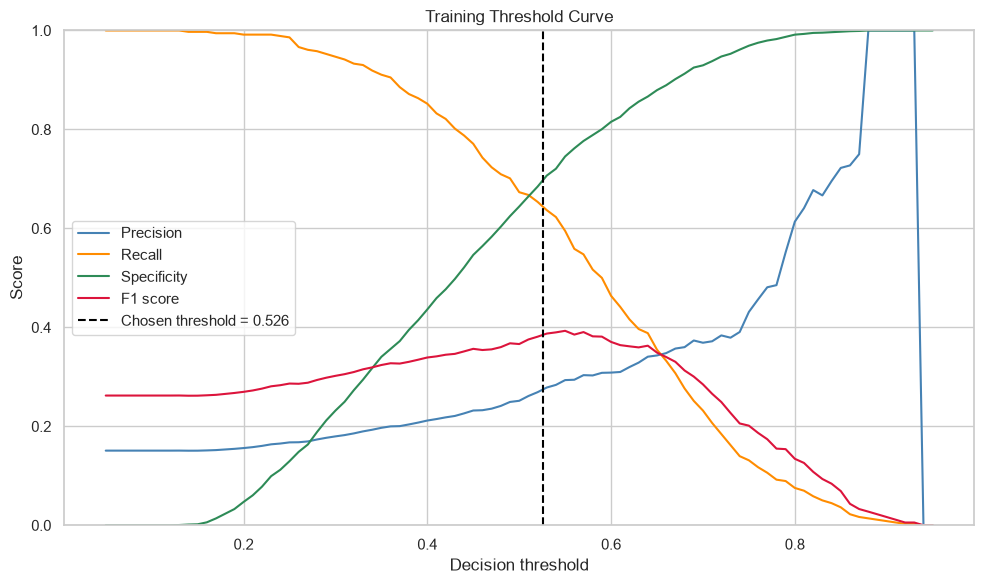

In [112]:
threshold_grid = np.linspace(0.05, 0.95, 91)
threshold_rows = []

for threshold in threshold_grid:
    threshold_pred = (oof_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, threshold_pred).ravel()
    specificity_at_threshold = tn / (tn + fp) if (tn + fp) > 0 else 0

    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_train, threshold_pred, zero_division=0),
        'recall': recall_score(y_train, threshold_pred, zero_division=0),
        'specificity': specificity_at_threshold,
        'f1': f1_score(y_train, threshold_pred, zero_division=0)
    })

threshold_curve = pd.DataFrame(threshold_rows)

plt.figure(figsize=(10, 6))
plt.plot(threshold_curve['threshold'], threshold_curve['precision'], label='Precision', color='steelblue')
plt.plot(threshold_curve['threshold'], threshold_curve['recall'], label='Recall', color='darkorange')
plt.plot(threshold_curve['threshold'], threshold_curve['specificity'], label='Specificity', color='seagreen')
plt.plot(threshold_curve['threshold'], threshold_curve['f1'], label='F1 score', color='crimson')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Chosen threshold = {best_threshold:.3f}')
plt.title('Training Threshold Curve')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

This threshold is chosen from training-only cross-validated probabilities, so it is still an internal model-development decision rather than a test-set optimisation. That is the correct place to tune the sensitivity-specificity tradeoff.

## Evaluate on the Test Set

After preprocessing, feature selection, model tuning, and threshold choice are frozen, the model is refit on the training data and evaluated once on the untouched test set. The cell compares the default threshold with the training-optimised threshold.

In [34]:
best_model.fit(X_train_selected, y_train)

test_proba = best_model.predict_proba(X_test_selected)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred = (test_proba >= best_threshold).astype(int)

metrics_table = pd.DataFrame([
    {
        'threshold': 0.5,
        'accuracy': accuracy_score(y_test, test_pred_default),
        'precision': precision_score(y_test, test_pred_default, zero_division=0),
        'recall': recall_score(y_test, test_pred_default, zero_division=0),
        'f1': f1_score(y_test, test_pred_default, zero_division=0),
        'roc_auc': roc_auc_score(y_test, test_proba)
    },
    {
        'threshold': best_threshold,
        'accuracy': accuracy_score(y_test, test_pred),
        'precision': precision_score(y_test, test_pred, zero_division=0),
        'recall': recall_score(y_test, test_pred, zero_division=0),
        'f1': f1_score(y_test, test_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, test_proba)
    }
])

print('Test-set metrics comparison:')
display(metrics_table.round(3))

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print('Confusion matrix at the optimized threshold:')
print(cm)
print('\nClassification report at the optimized threshold:')
print(classification_report(y_test, test_pred, zero_division=0))
print('Specificity at the optimized threshold:', round(specificity, 3))



Test-set metrics comparison:


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.500,0.687,0.279,0.680,0.395,0.731
1,0.526,0.716,0.293,0.627,0.399,0.731


Confusion matrix at the optimized threshold:
[[632 232]
 [ 57  96]]

Classification report at the optimized threshold:
              precision    recall  f1-score   support

           0       0.92      0.73      0.81       864
           1       0.29      0.63      0.40       153

    accuracy                           0.72      1017
   macro avg       0.60      0.68      0.61      1017
weighted avg       0.82      0.72      0.75      1017

Specificity at the optimized threshold: 0.731


This is the first point where the test set is used for performance measurement. Comparing the default and optimized thresholds makes the screening tradeoff explicit: the optimized threshold often improves recall, while precision may remain limited in an imbalanced medical classification problem.

## Interpret Model Coefficients

Logistic regression remains attractive because its coefficients are interpretable. The next cell converts coefficients to odds ratios so the direction and relative strength of each selected feature can be read more directly.

In [35]:
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': best_model.named_steps['model'].coef_[0]
})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False).reset_index(drop=True)
display(coef_df.round(3))

,feature,coefficient,odds_ratio
0,age,0.419,1.521
1,cigsPerDay,0.253,1.288
2,sysBP,0.251,1.285
3,sex,0.151,1.164
4,diabetes,0.136,1.146
5,totChol,0.129,1.137
6,prevalentHyp,0.127,1.135
7,BPMeds,0.034,1.034


The table above converts coefficients into clinically readable statements. Instead of only reporting technical values, it explains how each feature shifts CHD odds in practical terms (for example, “about X% higher odds”). That supports real-world decision making: features with larger positive odds impact should push clinicians to prioritize cardiovascular screening and follow-up.

It is important to note that these are model-based associations, not proof of causation. Still, because the directions align with known cardiovascular risk pathways (age, blood pressure, diabetes-related status, smoking burden), they are useful for risk triage and preventive planning.

## Limitations and Recommendations

### Limitation: Limited Feature Set
The model was built using the variables available in this dataset, but some clinically important predictors may be missing. Examples include family history, medication duration and adherence, richer lifestyle details, and longitudinal measurements over time. Because these factors are not included, the model's predictive ceiling may be constrained even if the modeling pipeline is well tuned.

### Recommendation: External Validation for Generalizability
To confirm that the model truly works beyond this single dataset, validate it on an independent external cohort from a different population or clinical setting. This step is important because a model that performs well on one dataset may not generalize equally well elsewhere due to differences in demographics, measurement practices, or disease prevalence. External validation will give stronger evidence that the model is robust and suitable for real-world use.

## Conclusions

The final cell turns the measured test results into a concise project conclusion. It summarises discrimination, recall, precision, and the practical use case of the model as a screening aid rather than a standalone diagnostic tool.

In [36]:
final_metrics = metrics_table.round(3)
optimized_metrics = final_metrics.loc[final_metrics['threshold'] != 0.5].iloc[0]

print(
    'Conclusion: The tuned logistic regression model provides moderate discrimination for 10-year CHD risk and is better suited for screening than for definitive diagnosis.'
)
print(
    f"At the optimized threshold, accuracy is {optimized_metrics['accuracy']:.3f}, precision is {optimized_metrics['precision']:.3f}, recall is {optimized_metrics['recall']:.3f}, F1 is {optimized_metrics['f1']:.3f}, and ROC AUC is {optimized_metrics['roc_auc']:.3f}."
)
print(
    'Recommendation: Use the model to flag higher-risk patients for further clinical review, not as a replacement for clinician judgment.'
)

Conclusion: The tuned logistic regression model provides moderate discrimination for 10-year CHD risk and is better suited for screening than for definitive diagnosis.
At the optimized threshold, accuracy is 0.716, precision is 0.293, recall is 0.627, F1 is 0.399, and ROC AUC is 0.731.
Recommendation: Use the model to flag higher-risk patients for further clinical review, not as a replacement for clinician judgment.


The conclusion stays tied to the measured test results rather than over-claiming performance. That is especially important in a healthcare setting, where moderate recall can still be useful for screening but limited precision means follow-up assessment remains necessary.